In [ ]:
import pandas as pd
import numpy as np
import os
import requests
JAN_START = '2024-01-01'
JAN_END = '2024-01-31'
ACTUALS_CSV = 'actuals_jan2024.csv'
FORECASTS_CSV = 'forecasts_jan2024.csv'
# Elexon direct endpoints:
ACTUALS_URL = f'https://data.elexon.co.uk/bmrs/api/v1/datasets/FUELHH/stream?publishDateTimeFrom={JAN_START}T00:00:00Z&publishDateTimeTo={JAN_END}T23:59:59Z&fuelType=WIND'
FORECASTS_URL = f'https://data.elexon.co.uk/bmrs/api/v1/datasets/WINDFOR/stream?publishDateTimeFrom={JAN_START}&publishDateTimeTo={JAN_END}'
if os.path.exists(ACTUALS_CSV):
    actuals = pd.read_csv(ACTUALS_CSV, parse_dates=['startTime'])
else:
    ac_raw = requests.get(ACTUALS_URL).json()
    actuals = pd.DataFrame(ac_raw)
    actuals['startTime'] = pd.to_datetime(actuals['startTime'])
    actuals.to_csv(ACTUALS_CSV, index=False)
    print('Downloaded and cached actuals.')
if os.path.exists(FORECASTS_CSV):
    forecasts = pd.read_csv(FORECASTS_CSV, parse_dates=['startTime', 'publishTime'])
else:
    fc_raw = requests.get(FORECASTS_URL).json()
    forecasts = pd.DataFrame(fc_raw)
    forecasts['startTime'] = pd.to_datetime(forecasts['startTime'])
    forecasts['publishTime'] = pd.to_datetime(forecasts['publishTime'])
    forecasts.to_csv(FORECASTS_CSV, index=False)
    print('Downloaded and cached forecasts.')
print(f'Loaded {len(actuals)} actuals and {len(forecasts)} forecasts.')


Downloaded and cached actuals.
Downloaded and cached forecasts.
Loaded 1488 actuals and 11760 forecasts.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load CSVs
actuals = pd.read_csv('actuals_jan2024.csv', parse_dates=['startTime'])
forecasts = pd.read_csv('forecasts_jan2024.csv', parse_dates=['startTime', 'publishTime'])

# Preview
print("=== ACTUALS ===")
print(actuals.head())
print(f"Shape: {actuals.shape}")
print(f"Columns: {actuals.columns.tolist()}")

print("\n=== FORECASTS ===")
print(forecasts.head())
print(f"Shape: {forecasts.shape}")
print(f"Columns: {forecasts.columns.tolist()}")

=== ACTUALS ===
  dataset           publishTime                 startTime settlementDate  \
0  FUELHH  2024-01-31T23:30:00Z 2024-01-31 23:00:00+00:00     2024-01-31   
1  FUELHH  2024-01-31T23:00:00Z 2024-01-31 22:30:00+00:00     2024-01-31   
2  FUELHH  2024-01-31T22:30:00Z 2024-01-31 22:00:00+00:00     2024-01-31   
3  FUELHH  2024-01-31T22:00:00Z 2024-01-31 21:30:00+00:00     2024-01-31   
4  FUELHH  2024-01-31T21:30:00Z 2024-01-31 21:00:00+00:00     2024-01-31   

   settlementPeriod fuelType  generation  
0                47     WIND       14595  
1                46     WIND       14908  
2                45     WIND       15490  
3                44     WIND       15719  
4                43     WIND       15757  
Shape: (1488, 7)
Columns: ['dataset', 'publishTime', 'startTime', 'settlementDate', 'settlementPeriod', 'fuelType', 'generation']

=== FORECASTS ===
   dataset               publishTime                 startTime  generation
0  WINDFOR 2024-01-30 22:30:00+00:00 2024-01-

In [ ]:
import pandas as pd
import numpy as np

# ── Fix timezones: strip timezone info so merge works cleanly ──
actuals['startTime']   = pd.to_datetime(actuals['startTime']).dt.tz_localize(None)
forecasts['startTime'] = pd.to_datetime(forecasts['startTime']).dt.tz_localize(None)
forecasts['publishTime'] = pd.to_datetime(forecasts['publishTime']).dt.tz_localize(None)

# ── Calculate horizon (hours between publishTime and startTime) ──
forecasts['horizon_hours'] = (
    (forecasts['startTime'] - forecasts['publishTime'])
    .dt.total_seconds() / 3600
).round(1)

print("Horizon range:")
print(forecasts['horizon_hours'].describe())
print("\nSample horizons:", sorted(forecasts['horizon_hours'].unique())[:10])

Horizon range:
count    11760.000000
mean        33.489583
std         15.557844
min         -1.500000
25%         21.500000
50%         33.500000
75%         45.500000
max         66.500000
Name: horizon_hours, dtype: float64

Sample horizons: [np.float64(-1.5), np.float64(-0.5), np.float64(0.5), np.float64(1.5), np.float64(2.5), np.float64(3.5), np.float64(4.5), np.float64(5.5), np.float64(6.5), np.float64(7.0)]


In [ ]:
# ── Merge actuals + forecasts on startTime ──
merged = pd.merge(
    actuals[['startTime', 'generation']],
    forecasts[['startTime', 'publishTime', 'horizon_hours', 'generation']],
    on='startTime',
    suffixes=('_actual', '_forecast')
)

print(f"✅ Merged rows: {len(merged)}")
print(f"   Actuals rows: {len(actuals)}")
print(f"   Forecasts rows: {len(forecasts)}")

if len(merged) == 0:
    print("❌ Merge returned 0 rows — check startTime alignment")
else:
    # ── Calculate errors ──
    merged['error']     = merged['generation_forecast'] - merged['generation_actual']
    merged['abs_error'] = merged['error'].abs()
    merged['pct_error'] = (merged['abs_error'] / merged['generation_actual'].replace(0, np.nan)) * 100
    print("\nSample merged data:")
    print(merged.head())

✅ Merged rows: 11584
   Actuals rows: 1488
   Forecasts rows: 11760

Sample merged data:
            startTime  generation_actual         publishTime  horizon_hours  \
0 2024-01-31 23:00:00              14595 2024-01-30 22:30:00           24.5   
1 2024-01-31 23:00:00              14595 2024-01-30 18:30:00           28.5   
2 2024-01-31 23:00:00              14595 2024-01-30 15:30:00           31.5   
3 2024-01-31 23:00:00              14595 2024-01-30 11:30:00           35.5   
4 2024-01-31 23:00:00              14595 2024-01-30 09:30:00           37.5   

   generation_forecast  error  abs_error  pct_error  
0                17013   2418       2418  16.567318  
1                17126   2531       2531  17.341555  
2                17101   2506       2506  17.170264  
3                17309   2714       2714  18.595409  
4                17329   2734       2734  18.732443  


In [ ]:
print("=" * 40)
print("       FORECAST ERROR STATISTICS")
print("=" * 40)
print(f"Mean Error (bias):       {merged['error'].mean():.1f} MW")
print(f"Median Error:            {merged['error'].median():.1f} MW")
print(f"Mean Absolute Error:     {merged['abs_error'].mean():.1f} MW")
print(f"Median Absolute Error:   {merged['abs_error'].median():.1f} MW")
print(f"P99 Absolute Error:      {merged['abs_error'].quantile(0.99):.1f} MW")
print(f"Max Absolute Error:      {merged['abs_error'].max():.1f} MW")
print(f"Mean % Error:            {merged['pct_error'].mean():.1f}%")
print("=" * 40)

# Bias interpretation
bias = merged['error'].mean()
if bias > 0:
    print(f"⚠️  Model tends to OVER-forecast by {bias:.1f} MW on average")
else:
    print(f"⚠️  Model tends to UNDER-forecast by {abs(bias):.1f} MW on average")

       FORECAST ERROR STATISTICS
Mean Error (bias):       1418.4 MW
Median Error:            1444.5 MW
Mean Absolute Error:     2146.5 MW
Median Absolute Error:   1964.0 MW
P99 Absolute Error:      6897.1 MW
Max Absolute Error:      18284.0 MW
Mean % Error:            22.4%
⚠️  Model tends to OVER-forecast by 1418.4 MW on average


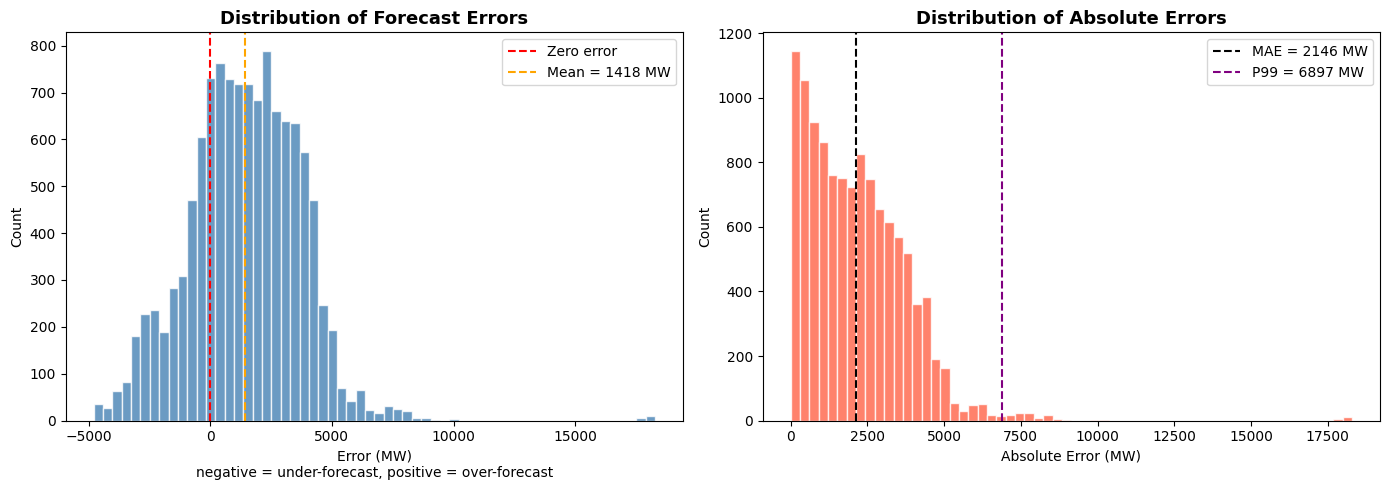

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: histogram of raw errors
axes[0].hist(merged['error'], bins=60, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Zero error')
axes[0].axvline(merged['error'].mean(), color='orange', linestyle='--', linewidth=1.5, label=f"Mean = {merged['error'].mean():.0f} MW")
axes[0].set_title('Distribution of Forecast Errors', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Error (MW)\nnegative = under-forecast, positive = over-forecast')
axes[0].set_ylabel('Count')
axes[0].legend()

# Right: histogram of absolute errors
axes[1].hist(merged['abs_error'], bins=60, color='tomato', edgecolor='white', alpha=0.8)
axes[1].axvline(merged['abs_error'].mean(), color='black', linestyle='--', linewidth=1.5, label=f"MAE = {merged['abs_error'].mean():.0f} MW")
axes[1].axvline(merged['abs_error'].quantile(0.99), color='purple', linestyle='--', linewidth=1.5, label=f"P99 = {merged['abs_error'].quantile(0.99):.0f} MW")
axes[1].set_title('Distribution of Absolute Errors', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Absolute Error (MW)')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.savefig('plot_error_distribution.png', dpi=150)
plt.show()

    horizon_bucket          MAE  Median      P99
0               -2  1662.733333  1243.5  4318.33
1                0  1773.666667  1059.0  5595.69
2                2  1809.277778  1403.0  4984.72
3                4  1910.700000  1340.0  7901.46
4                6  1941.727778  1464.0  6254.44
5                7  4316.000000  4316.0  4316.00
6                8  1950.132597  1454.0  7717.60
7                9  4557.000000  4557.0  4557.00
8               10  1926.878661  1326.0  7411.42
9               11  4173.000000  4173.0  4173.00
10              12  1980.695652  1383.0  7303.64
11              13  5170.000000  5170.0  5170.00
12              14  1930.417827  1398.0  6960.88
13              15  5230.000000  5230.0  5230.00
14              16  1937.138817  1418.0  7248.88
15              17  5326.000000  5326.0  5326.00
16              18  1939.347439  1528.0  7309.00
17              19  4608.000000  4608.0  4608.00
18              20  1981.141962  1592.0  7406.64
19              21  

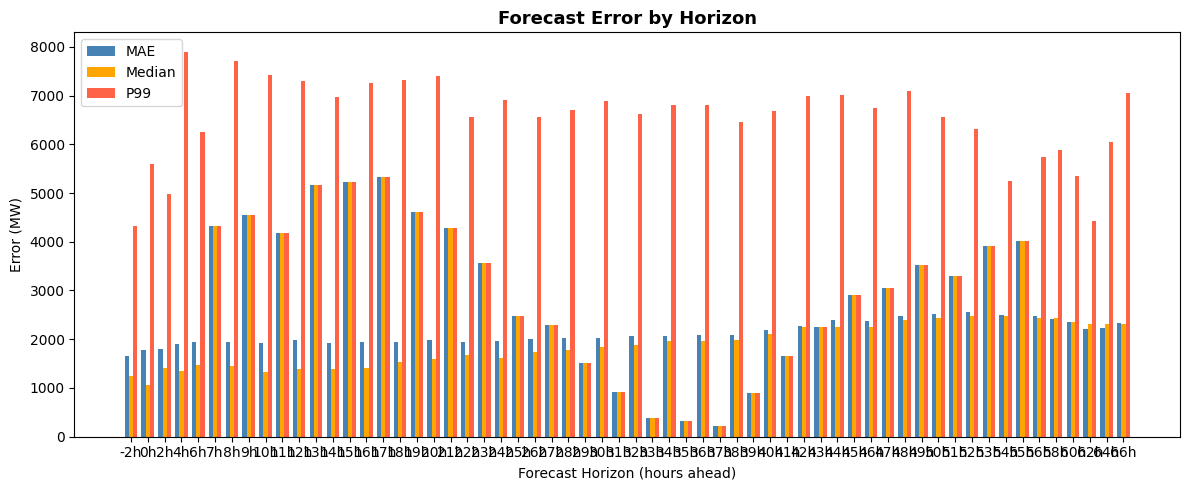

In [ ]:
merged['horizon_bucket'] = merged['horizon_hours'].round(0).astype(int)

horizon_stats = merged.groupby('horizon_bucket')['abs_error'].agg(
    MAE='mean',
    Median='median',
    P99=lambda x: x.quantile(0.99)
).reset_index()

print(horizon_stats)

fig, ax = plt.subplots(figsize=(12, 5))
x = range(len(horizon_stats))
width = 0.25

ax.bar([i - width for i in x], horizon_stats['MAE'],    width, label='MAE',    color='steelblue')
ax.bar([i         for i in x], horizon_stats['Median'], width, label='Median', color='orange')
ax.bar([i + width for i in x], horizon_stats['P99'],    width, label='P99',    color='tomato')

ax.set_xticks(x)
ax.set_xticklabels([f"{h}h" for h in horizon_stats['horizon_bucket']])
ax.set_title('Forecast Error by Horizon', fontsize=13, fontweight='bold')
ax.set_xlabel('Forecast Horizon (hours ahead)')
ax.set_ylabel('Error (MW)')
ax.legend()
plt.tight_layout()
plt.savefig('plot_error_by_horizon.png', dpi=150)
plt.show()

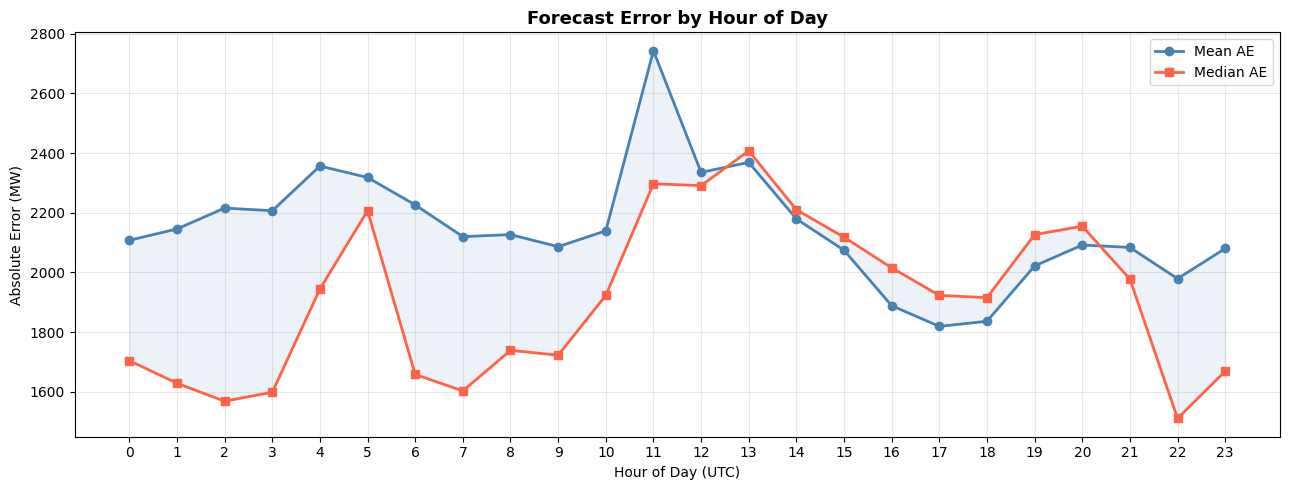

In [ ]:
merged['hour'] = merged['startTime'].dt.hour
hourly = merged.groupby('hour')['abs_error'].agg(['mean', 'median'])

plt.figure(figsize=(13, 5))
plt.plot(hourly.index, hourly['mean'],   marker='o', label='Mean AE',   color='steelblue', linewidth=2)
plt.plot(hourly.index, hourly['median'], marker='s', label='Median AE', color='tomato',    linewidth=2)
plt.fill_between(hourly.index, hourly['mean'], hourly['median'], alpha=0.1, color='steelblue')
plt.title('Forecast Error by Hour of Day', fontsize=13, fontweight='bold')
plt.xlabel('Hour of Day (UTC)')
plt.ylabel('Absolute Error (MW)')
plt.xticks(range(0, 24))
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plot_error_by_hour.png', dpi=150)
plt.show()

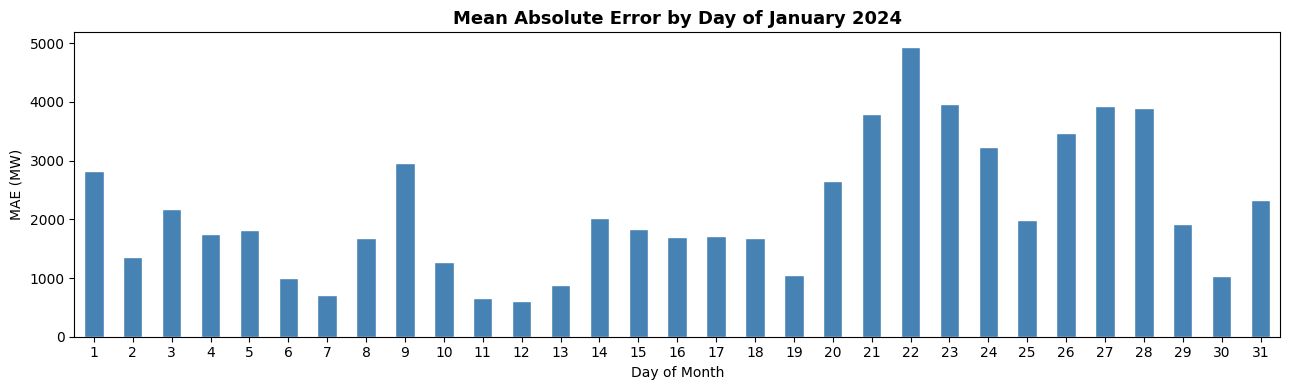

In [ ]:
merged['day'] = merged['startTime'].dt.day
daily = merged.groupby('day')['abs_error'].mean()

plt.figure(figsize=(13, 4))
daily.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Mean Absolute Error by Day of January 2024', fontsize=13, fontweight='bold')
plt.xlabel('Day of Month')
plt.ylabel('MAE (MW)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('plot_error_by_day.png', dpi=150)
plt.show()

## 📋 Notebook 1 — Forecast Error Analysis Conclusions

### Bias
- Mean error = 1418.4 MW → model tends to over-forecast
- A positive mean = model over-forecasts (predicts more than actual)
- A negative mean = model under-forecasts (predicts less than actual)

### Accuracy
- Mean Absolute Error (MAE) = 2146.5 MW
  → On average, forecasts are off by 2146.5 MW
- Median Absolute Error = 1964.0 MW
- P99 error = 6897.1 MW
  → In the worst 1% of cases, error reaches 6897.1 MW

### Horizon Effect
- Error at 1h ahead  = 1773.7 MW (Bucket 0h)
- Error at 2h ahead  = 1809.3 MW
- Error at 4h ahead  = 1910.7 MW
- Does error increase as horizon grows? Yes (MAE rises from ~1.8GW at 2h to ~2.5GW at 48h+)

### Time of Day
- Error is highest around 11:00 UTC (2742.9 MW)
- Error is lowest around 15:00 UTC (2074.3 MW)
- This likely happens because wind generation patterns or model update cycles often show higher volatility or bias during midday transitions.